## Exploring New Emergence of Varianty
**Author:** Karen Guzman

**Description:** Exploring different values of susceptible, infected, and recovered individuals with two variants. We introduce the new variant's transmission rate, beta2.


**Date:** 6/19/2026

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../models')
#imports
import numpy as np
import matplotlib.pyplot as plt
import new_emergence as ne

**Exploring difference scenarios**

**Scenario 1:** Emergence of variant 2 long after variant 1

R0 (variant 1): 1.27
R0 (variant 2): 7.08
Effective R0 (variant 2 at emergence): 3.76
Peak of Strain 1: 53 at t=10.5
Peak of Strain 2: 204 at t=172.2
Total infected with Strain 1: 468
Total infected with Strain 2: 518
Never infected (final S): 14
Figure saved to figures/emergence_scenario_1.png


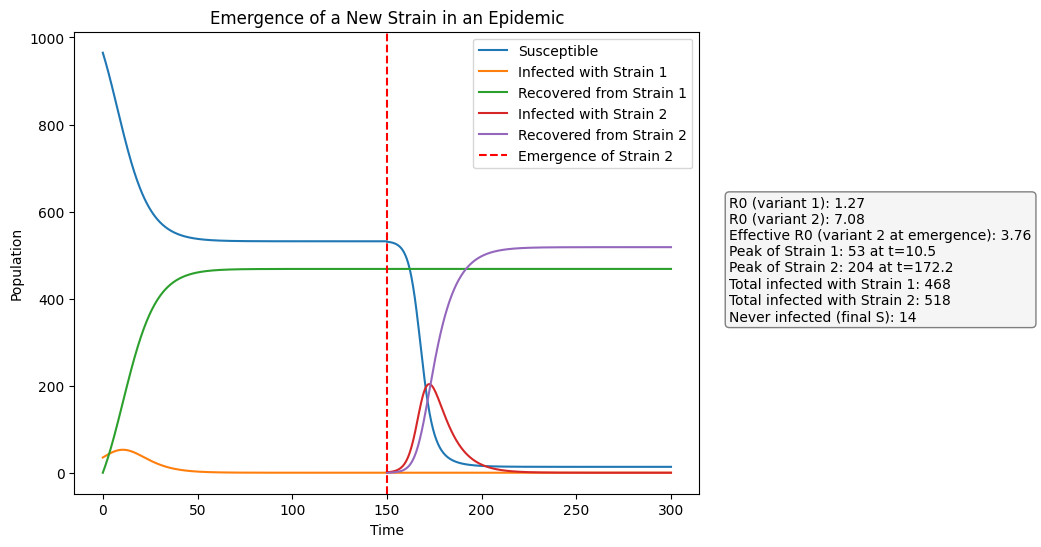

In [2]:
#where variant 2 emerges and takes over
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=150)

ne.plot_emergence(t, y, params, filename="emergence_scenario_1.png")

Variant 1 $(R_0 = 1.27)$ produces an early wave at around $t = 10$ and burns out long before variant 2 appears, infecting about 468 of the population in total. Variant 2 emerges at $t = 150$ into a population that is already about half-immune. Although its intrinsic transmissibility is high $(R_0 = 7.08)$, its effective reproduction number at emergence is only 3.76, since prior infection with variant 1 has removed about half the susceptible pool. It still spreads successfully, infecting about 518 people. Since each person catches at most one variant, the two strains end up infecting different halves of the population: a total of 986 people and leaving only about 14 who have never been infected by either. 

**Scenario 2:** Variant 1 and 2 circulating at the same time

R0 (variant 1): 1.27
R0 (variant 2): 7.08
Effective R0 (variant 2 at emergence): 5.88
Peak of Strain 1: 53 at t=10.4
Peak of Strain 2: 309 at t=23.9
Total infected with Strain 1: 339
Total infected with Strain 2: 655
Never infected (final S): 6
Figure saved to figures/emergence_scenario_2.png


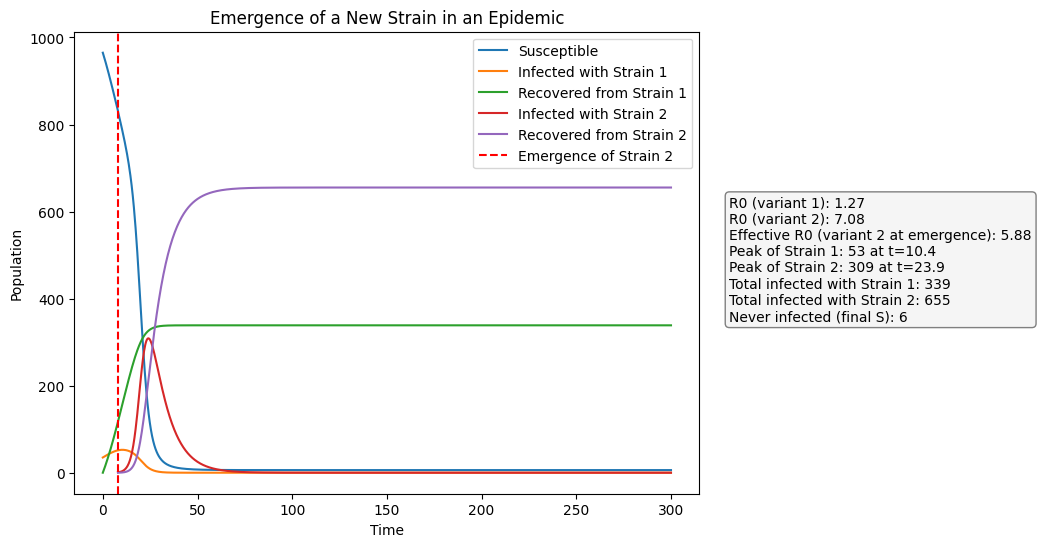

In [3]:
#same params as variant 1, changing emergence time to 8 days
params = [0.42, 0.85, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=8)

ne.plot_emergence(t, y, params, filename="emergence_scenario_2.png")

Variant 2 emerges at $t = 8$, while variant 1 is still actively spreading, so the two strains circulate simultaneously and compete for the same susceptible pool. Because variant 2 arrives before variant 1 has infected much of the susceptible population, its effective reproduction number at emergence stays high (5.88, close to its intrinsic $R_0 = 7.08$). Its much greater transmissibility dominates variant 1's ($R_0 = 1.27$). In total, about 665 people are infected by variant 2 and 339 are infected by variant 1. This leaves 6 that are never infected. This scenario shows the reverse of the late-emergence case, where variant 2's effective $R_0$ was limited by the prior immunity caused by variant 1 and barely won. 

**Scenario 3:** Variant 2 emerges and fails to take over

R0 (variant 1): 1.27
R0 (variant 2): 0.92
Effective R0 (variant 2 at emergence): 0.76
Peak of Strain 1: 53 at t=10.4
Peak of Strain 2: 1 at t=8.0
Total infected with Strain 1: 466
Total infected with Strain 2: 2
Never infected (final S): 531
Figure saved to figures/emergence_scenario_3.png


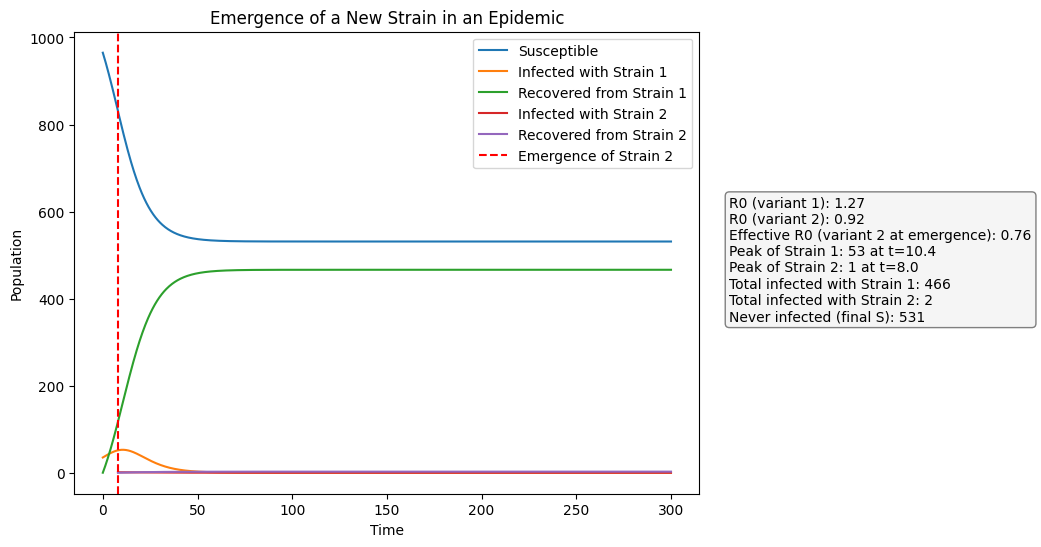

In [4]:
#variant 2 emerges but does not take over
params = [.42, 0.11, 0.33, 0.12] #beta1, beta2, gamma1, gamma2
y0 = [965, 35, 0, 0, 0] # 965 susceptible, 35 infected with strain 1, 0 infected with strain 2, 0 recovered from strain 1, 0 recovered from strain 2
t, y = ne.simulate_emergence(params, y0, t_emerge=8)

ne.plot_emergence(t, y, params, filename="emergence_scenario_3.png")

In this scenario, variant 2 emerges but does not take over. It emerges at $t = 8$ into a large susceptible pool, but with $R_0 = 0.92 <1$, each case produces fewer than the last case on average. The transmission can't sustain itself and the variant dies out almost immediately (peak of 1, with only 2 people ever infected). Because its intrinsic $R_0$ is already below the epidemic threshold, this failure to emerge is due to the variant's low transmissibility. Variant 1 is still successful, infecting 466 individuals and leaving 531 never infected by either strain.